# Scientific Machine Learning HW 1: Support Vector Machines and Phase Transition of Ising Model

In [1]:
import numpy as np
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Prepare Data

In [2]:
# The data consists of 16 * 10000 samples taken in T = {0.25, 0.5, ..., 4.}.
# Each sample consists of spins in a 40 * 40 lattice.
temps = np.repeat(np.linspace(0.25, 4., 16), 10000)
T_c = 2 / np.log(1 + np.sqrt(2))
# The first 9 * 10000 samples are ordered (label 1).
# The remaining 7 * 10000 samples are disordered (label 0).
data_file_name = "Ising2DFM_reSample_L40_T=All.pkl"
label_file_name = "Ising2DFM_reSample_L40_T=All_labels.pkl"

with open(data_file_name, "rb") as pickle_file:
    data = pickle.load(pickle_file)
data = np.unpackbits(data).reshape(-1, 1600).astype(int)
data[np.where(data==0)] = -1

# Label is 1 for ordered states and 0 for disordered states
with open(label_file_name, "rb") as pickle_file:
    labels = pickle.load(pickle_file)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (160000, 1600)
Labels: [0 1]


In [3]:
# 75% train, 25% test
data_train, data_test, labels_train, labels_test, temps_train, temps_test = train_test_split(data, labels, temps, stratify = temps)

## Logistic Regression

In [ ]:
scorers = ["accuracy", "precision", "recall", "f1"]
lr_models = [LogisticRegressionCV(l1_ratios = (0,), scoring = scorer, max_iter = 1000,
                                  cv = StratifiedKFold(n_splits = 5, shuffle = True), n_jobs = -1,
                                  use_legacy_attributes = False)
             for scorer in scorers]

In [12]:
# Takes about 4 minutes on my laptop
for lr_model in tqdm(lr_models):
    lr_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

In [29]:
lr_scores = np.zeros(len(scorers))
lr_scores_temps = np.zeros((len(scorers), 16))

for i, lr_model in enumerate(tqdm(lr_models)):
    print("Metric: {}".format(lr_model.scoring))
    lr_scores[i] = lr_model.score(data_test, labels_test)
    print("Overall {}: {:.4f}".format(lr_model.scoring, lr_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        if lr_model.scoring == "recall" and temp > T_c:
            # Recall is ill-defined when there are no positive samples
            lr_scores_temps[i, j] = np.nan
        else:
            lr_scores_temps[i, j] = lr_model.score(data_test[temps_test == temp], labels_test[temps_test == temp])
    if lr_model.scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i]),
                                                 0.25 * (np.argmax(lr_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i]),
                                                  0.25 * (np.argmin(lr_scores_temps[i]) + 1)))
    else:
        # Precision and F1 are trivially 0 when there are no positive samples
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i, :9]),
                                                 0.25 * (np.argmax(lr_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i, :9]),
                                                  0.25 * (np.argmin(lr_scores_temps[i, :9]) + 1)))
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6516
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.2048 at T = 2.5

Metric: precision
Overall precision: 0.6211
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9971
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9760 at T = 2.25

Metric: f1
Overall f1: 0.7596
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9275 at T = 2.25



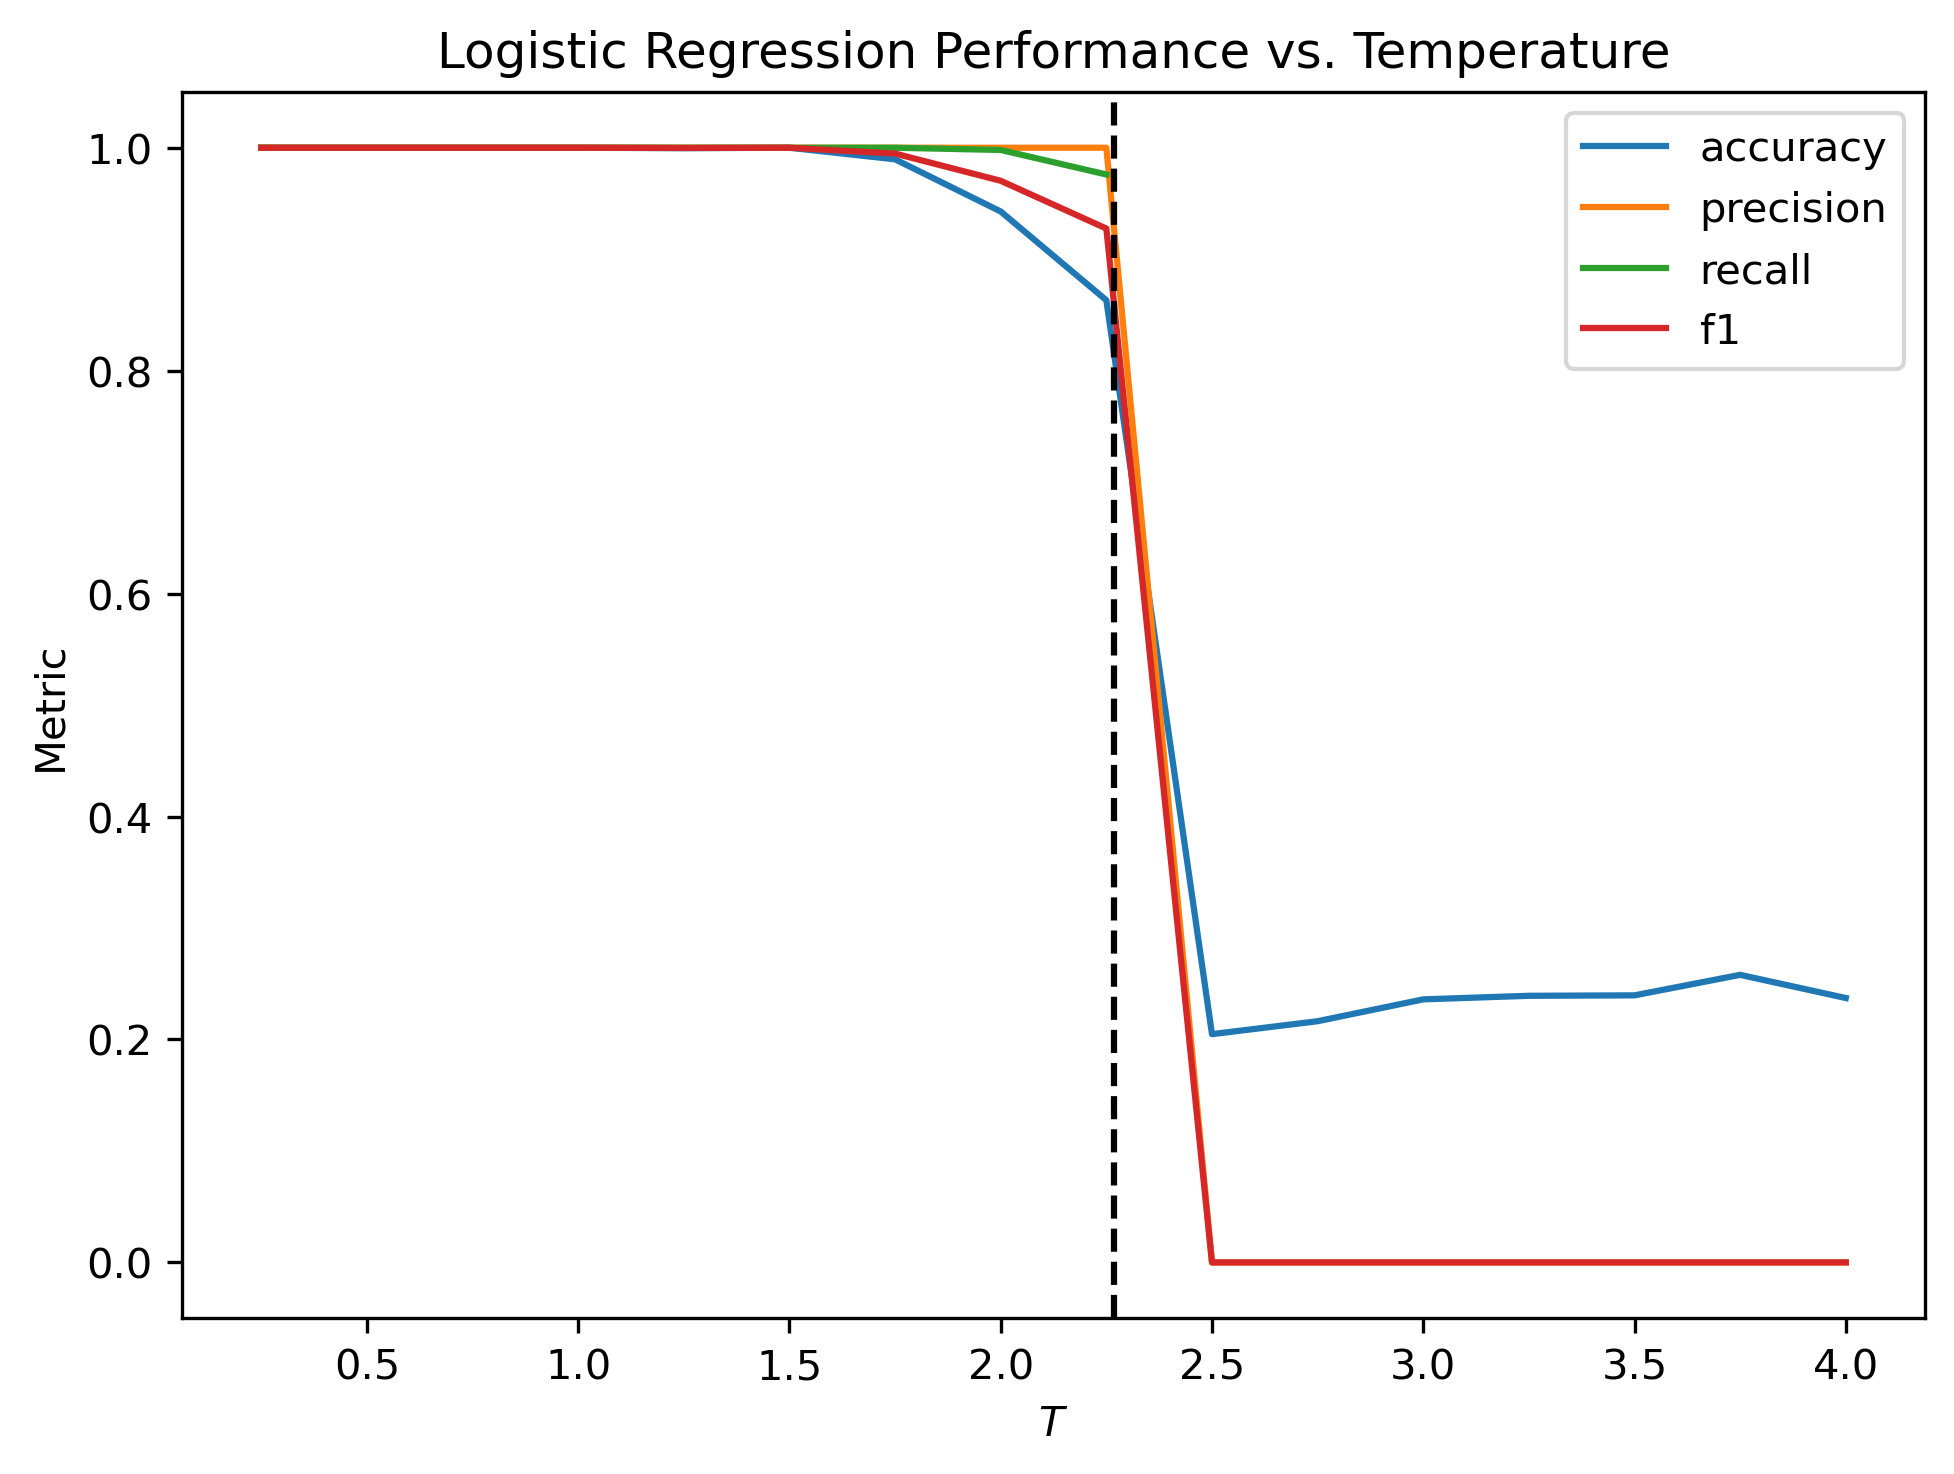

In [33]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(scorers):
    plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[i], label = scorer)
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Logistic Regression Performance vs. Temperature")
plt.legend()
plt.savefig("logistic.pdf")

## SVM

In [ ]:
p_grid = {
    "svc__kernel": ["linear", "rbf"],
}
svm = make_pipeline(StandardScaler(), SVC())

In [ ]:
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True)
outer_cv = StratifiedKFold(n_splits = 5, shuffle = True)

clf = GridSearchCV(estimator = svm, param_grid = p_grid, cv = inner_cv, n_jobs = -1)
# TODO: figure out n_jobs setting

In [ ]:
# nested_score = cross_val_score(clf, X = data_train, y = labels_train, cv = outer_cv, n_jobs = -1)

: 